# Train instance — classification (chapter 3)

One trainer for **instance-level classification** on Wav2Vec2-base. Twin of
`32_train_regression.ipynb` (ParlaSent logit + age): the run engine
(`run_phase`, the two-phase loop, run dirs, the stage-timing harness) is
**identical** across the two — only the task-specific cells differ. That
redundancy collapses into a shared utils module in phase E.

**Two-phase training:** phase 1 trains TRAIN→DEV every epoch (no model saved);
phase 2 retrains TRAIN∪DEV→TEST and saves the best epoch's model.

**Run tiers**
- **test mode** (`cfg.test_mode`) — tiny random model, 1 epoch, a couple dozen
  records. Proves the plumbing end-to-end; produces no real result.
- **demo run** — real model, real-but-capped data (`DEMO_*` caps), ~1–2 h.
  A tangible number, trivial (gender) or not (filled-pause count).
- **full run** — caps off (`None`), whole corpus. You and the GPU.

Target normalization is **regression-only** (lives in 32); classification has a
label space, so there's nothing to normalize here.

# Setup

In [1]:
import time

# ── Stage timing ───────────────────────────────────────────────────────────────
# Identical harness across 31/32 (lifts to utils in phase E). mark() stamps a
# milestone; the final cell prints a per-stage breakdown. Stdlib-only, cheap,
# partial-run safe (prints whatever marks exist).
STAGE_TIMES: dict[str, float] = {}

def mark(stage: str) -> None:
    STAGE_TIMES[stage] = time.time()

def fmt_mmss(seconds: float) -> str:
    s = int(round(max(0.0, seconds)))
    return f"{s // 60:02d}:{s % 60:02d}"

def print_stage_breakdown(times: dict[str, float]) -> None:
    items = list(times.items())
    if not items:
        print("no timing recorded")
        return
    width = max(len(k) for k, _ in items)
    print("stage timing (delta from previous mark)")
    print("-" * (width + 11))
    prev = items[0][1]
    for name, t in items:
        print(f"  {name:<{width}}  {fmt_mmss(t - prev)}")
        prev = t
    print("-" * (width + 11))
    print(f"  {'TOTAL':<{width}}  {fmt_mmss(items[-1][1] - items[0][1])}")

mark("literal start")

import os
import sys
from pathlib import Path

# Find PROJECT_ROOT via utils_dataprep (chapter 1 already does this).
HERE = Path.cwd()
if HERE.name != "3_instance_models":
    candidate = HERE / "3_instance_models"
    if candidate.exists():
        HERE = candidate
sys.path.insert(0, str(HERE.parent / "1_data_prep"))

import utils_dataprep as udp
PROJECT_ROOT = udp.PROJECT_ROOT

os.environ["HF_HOME"] = str(PROJECT_ROOT / "stock_models")
# Cache HF pretrained models in a project-local folder (gitignored) instead of
# ~/.cache/huggingface, so the download survives across machines / reclones.
# MUST be set BEFORE any `from transformers import ...` — HF reads HF_HOME at
# import time and caches the resolved path internally.

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Chapter dir  = {HERE}")
print(f"HF_HOME      = {os.environ['HF_HOME']}")

# ── GPU GUARD — MUST run before torch is imported (next cell) ─────────────────
# CUDA_VISIBLE_DEVICES only takes effect if set BEFORE the first torch.cuda call.
# GPU 2 is reserved for this project; we NEVER touch another GPU. No auto-arming:
# you must type 'y' to use the GPU. ENTER (or anything else) = CPU.
RESERVED_GPU = "2"
_env = os.environ.get("CONDA_DEFAULT_ENV", "")
print(f"\nconda env = {_env or '(none)'}")
print(f"⚠️  GPU mode will use PHYSICAL GPU {RESERVED_GPU} — and only GPU {RESERVED_GPU}.")
_choice = input(f"Use GPU {RESERVED_GPU}?  type 'y' for GPU {RESERVED_GPU}, anything else = CPU: ").strip().lower()
if _choice == "y":
    os.environ["CUDA_VISIBLE_DEVICES"] = RESERVED_GPU
    USE_CUDA = True
    print(f"🚀 GPU mode — CUDA_VISIBLE_DEVICES={RESERVED_GPU}  (physical GPU {RESERVED_GPU} → cuda:0 in-process)")
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    USE_CUDA = False
    print("🖥️  CPU mode")

PROJECT_ROOT = /cache/ivanp/projects/slavic-speech-pipeline
Chapter dir  = /cache/ivanp/projects/slavic-speech-pipeline/3_instance_models
HF_HOME      = /cache/ivanp/projects/slavic-speech-pipeline/stock_models

conda env = ssp-cuda
⚠️  GPU mode will use PHYSICAL GPU 2 — and only GPU 2.
🚀 GPU mode — CUDA_VISIBLE_DEVICES=2  (physical GPU 2 → cuda:0 in-process)


Standard third-party imports.

In [2]:
import gc
import json
import shutil
from collections import Counter
from dataclasses import dataclass, field
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torch
from datasets import Dataset
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoFeatureExtractor, AutoModelForAudioClassification,
    Trainer, TrainerCallback, TrainingArguments,
)

plt.rcParams["figure.dpi"] = 100

# Targets

What combinations of *(dataset, label)* this trainer can handle. Pick one via
`Config.target`; the resolver fills `jsonl_path`, `label_key`, `task_type`,
`label_order`. To add a target, add an entry here — `Config.target` is the only
downstream knob. `label_order: None` means "build it from the data union at load
time" (for many/unstable label spaces, e.g. `dialogue_act_function`).

In [3]:
TARGETS: dict = {
    # ---- ROG-Art (rog_instance.jsonl) ----------------------------------
    "rog_art_filled_pause": {
        "jsonl_path": "data/processed_jsonl/rog_instance.jsonl",
        "label_key":  "filled_pause_present",
        "task_type":  "classification",
        "label_order": [0, 1],
    },
    "rog_art_disfluency_count": {
        "jsonl_path": "data/processed_jsonl/rog_instance.jsonl",
        "label_key":  "disfluency_count",
        "task_type":  "classification",
        "label_order": [0, 1, 2],   # class 2 is ~0.5% of rows; macro-F1 will be brutal
    },

    # ---- ROG-Dialog (rog_dialog_instance.jsonl) ------------------------
    "rog_dia_sentiment": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "sentiment",
        "task_type":  "classification",
        "label_order": [
            "predominantlyNegative", "mixedNegative", "neutralNegative",
            "neutralPositive", "mixedPositive", "predominantlyPositive",
        ],
    },
    "rog_dia_sentiment_annotated": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "sentiment_annotated",
        "task_type":  "classification",
        "label_order": [
            "predominantlyNegative", "mixedNegative", "neutralNegative",
            "neutralPositive", "mixedPositive", "predominantlyPositive",
        ],
    },
    "rog_dia_dialogue_act_dimension": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "dialogue_act_dimension",
        "task_type":  "classification",
        # ~8 categories; non-ordinal, so Spearman is uninterpretable here.
        "label_order": [
            "task", "discourseStructuring", "autoFeedback", "timeManagement",
            "alloFeedback", "turnManagement", "ownCommunicationManagement",
            "unspecifiedDimension",
        ],
    },
    "rog_dia_dialogue_act_function": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "dialogue_act_function",
        "task_type":  "classification",
        # 30+ categories with a long tail; loader builds label_order from data.
        "label_order": None,
    },

    # ---- ParlaSpeech utterance_instance (generated per lang below) ------
}


def _add_parlaspeech_targets(targets: dict, langs=("hr", "rs", "pl", "cz")) -> None:
    """Classification utterance_instance targets per ParlaSpeech lang:
    gender + filled-pause presence/count. (sentiment_logit + age live in 32_regression.)"""
    for l in langs:
        path = f"data/processed_jsonl/parlaspeech_{l}_utterance_instance.jsonl"
        targets[f"parlaspeech_{l}_gender"] = {
            "jsonl_path": path, "label_key": "speaker_gender",
            "task_type": "classification", "label_order": ["M", "F"],
        }
        targets[f"parlaspeech_{l}_fp_present"] = {
            "jsonl_path": path, "label_key": "filled_pause_present",
            "task_type": "classification", "label_order": [0, 1],
        }
        targets[f"parlaspeech_{l}_fp_count"] = {
            "jsonl_path": path, "label_key": "filled_pause_count",
            "task_type": "classification", "label_order": None,  # built from data
        }


_add_parlaspeech_targets(TARGETS)


def resolve_target(cfg, targets: dict) -> None:
    """Overwrite jsonl_path/label_key/task_type/label_order from the picked
    preset. Mutates cfg in place. Raises if cfg.target isn't a known key."""
    if cfg.target not in targets:
        raise ValueError(
            f"Config.target={cfg.target!r} not in TARGETS. Known: {sorted(targets)}"
        )
    t = targets[cfg.target]
    cfg.jsonl_path  = t["jsonl_path"]
    cfg.label_key   = t["label_key"]
    cfg.task_type   = t["task_type"]
    cfg.label_order = t["label_order"]   # may be None — built from data later


print(f"available targets: {sorted(TARGETS)}")

available targets: ['parlaspeech_cz_fp_count', 'parlaspeech_cz_fp_present', 'parlaspeech_cz_gender', 'parlaspeech_hr_fp_count', 'parlaspeech_hr_fp_present', 'parlaspeech_hr_gender', 'parlaspeech_pl_fp_count', 'parlaspeech_pl_fp_present', 'parlaspeech_pl_gender', 'parlaspeech_rs_fp_count', 'parlaspeech_rs_fp_present', 'parlaspeech_rs_gender', 'rog_art_disfluency_count', 'rog_art_filled_pause', 'rog_dia_dialogue_act_dimension', 'rog_dia_dialogue_act_function', 'rog_dia_sentiment', 'rog_dia_sentiment_annotated']


# Config

All knobs are here.

- `task_type`: classification-only here (`32_regression` handles regression).
- `label_key`: which key inside `labels` to train on (e.g. `speaker_gender`,
  `filled_pause_present`).
- `label_order`: **required for classification** (canonical class order → `id2label`
  and ordinal Spearman). `None` → built from the data union at load time.
- `model_name`: `facebook/wav2vec2-base` (~95M). Test mode swaps in a tiny random model.
- `use_cuda`: honored from the GPU guard above; never touches a GPU other than 2.

`label_scale` / `loss_function` / `best_metric_regression` are regression-only
knobs kept here so the Config matches 32 (a single shared dataclass in phase E);
they're ignored for classification.

**Output layout**
- `runs/<run_name>/` — per-epoch logs, predictions, plots, config snapshot. Light (~MB).
- `models/<run_name>/best_model/` — final weights + best epoch's artifacts. Heavy.

**⚠️ CPU training of wav2vec2-base needs a few GB of working RAM** on top of the
OS + IDE. If RAM-bound: drop `batch_size` to 2 / `grad_accum` to 1, or train on GPU.

In [4]:
@dataclass
class Config:
    # -- Target preset (resolver overwrites the data fields below) -----------
    target: str = "parlaspeech_hr_gender"   # gender — proof-of-wiring demo target

    # -- Data (overwritten by resolve_target) -------------------------------
    jsonl_path:  str  = ""
    label_key:   str  = ""
    task_type:   str  = "classification"  # classification-only in this notebook
    label_order: list | None = None

    # Regression-only (kept for Config parity with 32; ignored here).
    label_scale: dict | None = None

    # -- Model ---------------------------------------------------------------
    model_name: str              = "facebook/wav2vec2-base"
    freeze_feature_encoder: bool = True
    loss_function: str           = "mse"   # regression only: "mse" | "l1"

    # -- Training ------------------------------------------------------------
    batch_size: int      = 16
    grad_accum: int      = 1
    learning_rate: float = 1e-5
    num_epochs: int      = 1      # demo runs often use 2–3 for a tangible curve
    max_grad_norm: float = 1.0
    warmup_ratio: float  = 0.10
    logging_steps: int   = 100

    # Rough ETA seed: train records processed per second (base model on GPU).
    # A deliberate guess — recalibrated from phase 1's real duration.
    eta_rec_per_s_guess: float = 40.0

    # -- Output --------------------------------------------------------------
    runs_dir: str   = "runs"
    models_dir: str = "models"

    # -- Best-epoch selection ------------------------------------------------
    best_metric_classification: str = "macro_f1"    # | "accuracy" | "spearman"
    best_metric_regression:     str = "spearman"    # | "mse" | "mae" (regression only)

    # -- Preprocessing -------------------------------------------------------
    preprocess_batch_size: int  = 32
    dataloader_num_workers: int = 16   # drop to 0–2 on the CPU box if RAM-bound
    map_num_proc: int = 8              # parallel workers for the .map() feature pass
    max_duration_s: float = 15.0       # drop instances longer than this (OOM guard)

    # -- Hardware ------------------------------------------------------------
    # Honored from the GPU guard (cell above). GPU 2 reserved; never touch others.
    use_cuda: bool   = True

    # -- Test mode -----------------------------------------------------------
    test_mode: bool       = False
    test_n_train: int     = 200
    test_n_dev: int       = 24
    test_n_test: int      = 24
    test_model_name: str  = "hf-internal-testing/tiny-random-wav2vec2"
    test_num_epochs: int  = 1
    test_batch_size: int  = 2


cfg = Config()
resolve_target(cfg, TARGETS)

# Apply test-mode clamps
if cfg.test_mode:
    udp.banner("🧪 TEST MODE", char="-")
    cfg.model_name = cfg.test_model_name
    cfg.num_epochs = cfg.test_num_epochs
    cfg.batch_size = cfg.test_batch_size
    cfg.grad_accum = 1
    cfg.runs_dir   = "runs/test"
    cfg.models_dir = "models/test"

# Device resolution. GPU selection + CUDA_VISIBLE_DEVICES already happened in the
# setup cell (input-gated) BEFORE torch was imported — the only point where
# pinning works. Here we just honor it; we do NOT touch CUDA_VISIBLE_DEVICES.
cfg.use_cuda = USE_CUDA
if cfg.use_cuda and torch.cuda.is_available():
    DEVICE = "cuda"   # = cuda:0 in-process, pinned to physical GPU 2
elif cfg.use_cuda and not torch.cuda.is_available():
    print("⚠️  GPU selected but torch.cuda.is_available()==False; falling back to CPU")
    DEVICE = "cpu"
else:
    DEVICE = "cpu"

print(f"target      = {cfg.target}")
print(f"jsonl_path  = {cfg.jsonl_path}")
print(f"label_key   = {cfg.label_key}")
print(f"task_type   = {cfg.task_type}")
print(f"label_order = {cfg.label_order}")
print(f"device      = {DEVICE}")
if DEVICE == "cuda":
    print(f"✓ visible devices : {torch.cuda.device_count()}  (CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')})")
    print(f"✓ device name     : {torch.cuda.get_device_name(0)}")

target      = parlaspeech_hr_gender
jsonl_path  = data/processed_jsonl/parlaspeech_hr_utterance_instance.jsonl
label_key   = speaker_gender
task_type   = classification
label_order = ['M', 'F']
device      = cuda
✓ visible devices : 1  (CUDA_VISIBLE_DEVICES=2)
✓ device name     : NVIDIA A100-PCIE-40GB


## Validate the config

Fail loud here so you don't burn hours of training only to learn a knob was wrong.

In [5]:
def validate_config(cfg: Config) -> None:
    if cfg.task_type != "classification":
        raise ValueError(f"31_ is classification-only; got task_type={cfg.task_type!r}. "
                         f"Use 32_train_regression for regression targets.")
    # label_order=None is allowed — it signals "build from data union after load".
    if cfg.label_order is not None and len(set(cfg.label_order)) != len(cfg.label_order):
        raise ValueError(f"label_order has duplicates: {cfg.label_order}")
    if cfg.best_metric_classification not in ("macro_f1", "accuracy", "spearman"):
        raise ValueError(f"best_metric_classification: invalid {cfg.best_metric_classification!r}")

validate_config(cfg)
print("✅ config valid")

✅ config valid


# Data

## Load JSONL, filter to records that carry `label_key`

Records missing the target label (or longer than `max_duration_s`) are dropped.
`DEMO_*` caps shrink TRAIN/DEV for a bounded demo run; TEST stays whole for a
trustworthy final number. Set a cap to `None` for the full run.

In [6]:
mark("data prep")

# ── Demo-run caps ─────────────────────────────────────────────────────────────
# Shuffle before slicing (JSONL is speaker-grouped, so a head-slice would skew
# the speaker/label balance). None → use the whole split (full run).
DEMO_TRAIN_CAP = 50_000
DEMO_DEV_CAP   = 10_000
DEMO_SEED      = 1234


def load_split(jsonl_path: str, split: str, label_key: str) -> list[dict]:
    out, n_long = [], 0
    for r in udp.iter_jsonl(jsonl_path):
        if r["split"] != split:
            continue
        if label_key not in r.get("labels", {}):
            continue
        if r["labels"][label_key] is None:
            continue
        if r.get("metadata", {}).get("audio_length", 0.0) > cfg.max_duration_s:
            n_long += 1
            continue
        out.append(r)
    if n_long:
        print(f"  dropped {n_long} {split} records > {cfg.max_duration_s}s")
    return out


train_records = load_split(cfg.jsonl_path, "train", cfg.label_key)
dev_records   = load_split(cfg.jsonl_path, "dev",   cfg.label_key)
test_records  = load_split(cfg.jsonl_path, "test",  cfg.label_key)

import random
if DEMO_TRAIN_CAP is not None and len(train_records) > DEMO_TRAIN_CAP:
    random.Random(DEMO_SEED).shuffle(train_records)
    train_records = train_records[:DEMO_TRAIN_CAP]
    print(f"🔬 demo: train capped to {DEMO_TRAIN_CAP} (shuffled, seed={DEMO_SEED})")
if DEMO_DEV_CAP is not None and len(dev_records) > DEMO_DEV_CAP:
    random.Random(DEMO_SEED).shuffle(dev_records)
    dev_records = dev_records[:DEMO_DEV_CAP]
    print(f"🔬 demo: dev capped to {DEMO_DEV_CAP} (shuffled, seed={DEMO_SEED})")

if cfg.test_mode:
    train_records = train_records[: cfg.test_n_train]
    dev_records   = dev_records[:   cfg.test_n_dev]
    test_records  = test_records[:  cfg.test_n_test]

print(f"train: {len(train_records)}")
print(f"dev:   {len(dev_records)}")
print(f"test:  {len(test_records)}")
if not train_records or not dev_records or not test_records:
    raise ValueError("one of the splits is empty after filtering for label_key — check the JSONL")


def rough_eta_seconds(n_train: int, n_dev: int, cfg: Config, rec_per_s: float) -> float:
    """Coarse wall-clock estimate: both phases train (TRAIN, then TRAIN∪DEV) for
    num_epochs at ~rec_per_s training records/second. Eval + preprocessing extra."""
    train_recs = (n_train * cfg.num_epochs) + ((n_train + n_dev) * cfg.num_epochs)
    return train_recs / max(1e-9, rec_per_s)


_eta = rough_eta_seconds(len(train_records), len(dev_records), cfg, cfg.eta_rec_per_s_guess)
print(f"\n⏱  rough ETA ~{fmt_mmss(_eta)} for {cfg.num_epochs} epoch(s) × 2 phases "
      f"(guess {cfg.eta_rec_per_s_guess:.0f} train-rec/s — approximate; "
      f"recalibrates after phase 1)")

  dropped 218431 train records > 15.0s
  dropped 25092 dev records > 15.0s
  dropped 22848 test records > 15.0s
🔬 demo: train capped to 50000 (shuffled, seed=1234)
🔬 demo: dev capped to 10000 (shuffled, seed=1234)
train: 50000
dev:   10000
test:  67884

⏱  rough ETA ~45:50 for 1 epoch(s) × 2 phases (guess 40 train-rec/s — approximate; recalibrates after phase 1)


## Labels & mappings

`label_order` is the source of truth: `label2id[label] = index in label_order`.
Any class in the data that isn't in `label_order` is a hard error. If the preset
left `label_order=None`, it's built from the data union here.

In [7]:
# If the target preset left label_order=None, build it from the data union.
if cfg.label_order is None:
    seen_vals = sorted({
        r["labels"][cfg.label_key]
        for r in (train_records + dev_records + test_records)
    }, key=str)
    cfg.label_order = seen_vals
    print(f"📌 auto-built label_order from data ({len(seen_vals)} classes): {seen_vals}")

label2id = {lab: i for i, lab in enumerate(cfg.label_order)}
id2label = {i: lab for i, lab in enumerate(cfg.label_order)}
num_labels = len(cfg.label_order)

# Validate all seen labels are in label_order
seen = {r["labels"][cfg.label_key] for r in (train_records + dev_records + test_records)}
unknown = seen - set(label2id)
if unknown:
    raise ValueError(
        f"Found labels not in Config.label_order: {sorted(map(str, unknown))}. "
        f"Either add them to label_order or fix the data."
    )

# Print per-split distribution
print(f"Labels ({num_labels}, canonical order):")
for lab in cfg.label_order:
    n_tr = sum(1 for r in train_records if r["labels"][cfg.label_key] == lab)
    n_dv = sum(1 for r in dev_records   if r["labels"][cfg.label_key] == lab)
    n_te = sum(1 for r in test_records  if r["labels"][cfg.label_key] == lab)
    print(f"   {str(lab):<28} train={n_tr:>4}  dev={n_dv:>4}  test={n_te:>4}")

Labels (2, canonical order):
   M                            train=39314  dev=6959  test=58159
   F                            train=10686  dev=3041  test=9725


# Training engine

Everything from here to just before the two phase calls is the shared engine:
feature extraction, collator, model, metrics, per-epoch artifacts, and
`run_phase`. This block is byte-identical to 32 except the task-specific bodies
(classification metrics / confusion matrices / long labels), so it lifts cleanly
to utils in phase E.

## Audio loading & feature extraction

`prepare_dataset_dict` turns canonical records into the list-of-dicts
`Dataset.from_list` wants. Provenance (`file_id`, `start_t`, `end_t`,
`audio_length`) is read from `metadata.*` so it actually lands in predictions.json.
`label_to_value` maps the class to its index in `label_order`.
`preprocess_function` loads each WAV (mono/16 kHz guaranteed by chapter 1) and
runs the feature extractor *without* padding — the collator pads per batch.

In [8]:
def label_to_value(r: dict, cfg: Config, label2id: dict | None) -> int:
    """Classification: map the original label to its index in label_order."""
    return label2id[r["labels"][cfg.label_key]]


def prepare_dataset_dict(records: list[dict], cfg: Config, label2id: dict | None) -> list[dict]:
    items = []
    for r in records:
        md = r.get("metadata", {})
        items.append({
            "instance_id":  r["instance_id"],
            "file_id":      r.get("file_id", ""),
            "start_t":      md.get("audio_start"),
            "end_t":        md.get("audio_end"),
            "audio_length": md.get("audio_length"),
            "audio_path":   str(udp.from_project_relative(r["audio_path"])),
            "label":        label_to_value(r, cfg, label2id),
            "label_class":  r["labels"][cfg.label_key],   # original value for reporting
        })
    return items


def preprocess_function(examples, feature_extractor):
    """Load each WAV via soundfile. Chapter-1 splitter guarantees 16 kHz mono PCM-16;
    we sanity-check and resample as a defensive fallback."""
    audio_arrays = []
    for path in examples["audio_path"]:
        data, sr = sf.read(path, dtype="float32", always_2d=False)
        if data.ndim == 2:
            data = data.mean(axis=1)
        if sr != 16000:
            import librosa
            data = librosa.resample(data, orig_sr=sr, target_sr=16000)
        audio_arrays.append(data)
    inputs = feature_extractor(
        audio_arrays, sampling_rate=16000, return_tensors=None, padding=False,
    )
    return {"input_values": inputs["input_values"], "labels": examples["label"]}

## Data collator (pad audio within each batch)

The feature extractor doesn't pad; this does — **and emits the `attention_mask`**
so the model's pooling excludes padded frames. (wav2vec2-base ships
`return_attention_mask=False`; we force it on at load and pass it explicitly
here. Without it the stock head mean-pools over padding.) Labels are class
indices (long) for classification.

In [9]:
class DataCollatorForInstance:
    """Pads audio within each batch and threads the attention mask through.
    Keeps the `task_type` arg for signature parity with 32_regression so
    `run_phase` stays identical across the two notebooks."""
    def __init__(self, feature_extractor, task_type: str = "classification"):
        self.feature_extractor = feature_extractor
        self.task_type = task_type

    def __call__(self, features):
        input_values = [f["input_values"] for f in features]
        labels = [f["labels"] for f in features]
        batch = self.feature_extractor.pad(
            {"input_values": input_values},
            padding=True, return_attention_mask=True, return_tensors="pt",
        )
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

## Model factory

`AutoModelForAudioClassification.from_pretrained(...)` — stock Wav2Vec2 sequence
head, nothing custom. With the collator's `attention_mask`, the head's pooling
ignores padded frames. `freeze_feature_encoder` freezes the CNN front-end.

In [10]:
def build_model(cfg: Config, num_labels: int, label2id, id2label):
    # HF transformers 5.x requires label2id keys to be str. Stringify here for
    # from_pretrained; the in-notebook label2id can keep native types.
    hf_label2id = {str(k): int(v) for k, v in label2id.items()}
    hf_id2label = {int(k): str(v) for k, v in id2label.items()}
    model = AutoModelForAudioClassification.from_pretrained(
        cfg.model_name,
        num_labels=num_labels,
        label2id=hf_label2id, id2label=hf_id2label,
        ignore_mismatched_sizes=True,
    )
    if cfg.freeze_feature_encoder:
        model.wav2vec2.freeze_feature_encoder()
        print("🔒 feature encoder (CNN) frozen")
    return model

## Metrics

Macro-F1, accuracy, Spearman (on class indices — only meaningful for ordinal
label spaces, but always reported).

In [11]:
def compute_classification_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    if len(set(labels)) > 1 and len(set(preds)) > 1:
        rho, _ = spearmanr(labels, preds)
        rho = float(rho) if not np.isnan(rho) else float("nan")
    else:
        rho = float("nan")
    return {"macro_f1": macro_f1, "accuracy": acc, "spearman": rho}


def get_compute_metrics(cfg: Config):
    return compute_classification_metrics

## Per-epoch artifacts

`predictions.json` (class labels + indices, correct provenance) and a confusion
matrix (counts + row-normalized %) with a `classification_report.txt` — one set
per epoch.

In [12]:
def save_predictions_json(predictions, labels, items, out_path: Path, task_type: str,
                          id2label: dict | None):
    out = []
    for i, item in enumerate(items):
        gold = int(labels[i])
        pred = int(np.argmax(predictions[i]))
        out.append({
            "instance_id": item["instance_id"],
            "file_id":     item.get("file_id", ""),
            "start_t":     item.get("start_t"),
            "end_t":       item.get("end_t"),
            "gold_label":  (id2label[gold] if id2label else gold),
            "pred_label":  (id2label[pred] if id2label else pred),
            "gold_raw":    float(gold),   # class index
            "pred_raw":    float(pred),   # class index (predicted)
        })
    out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))


def plot_confusion_matrix(y_true_idx, y_pred_idx, label_order: list, out_dir: Path):
    # Stringify labels for plot/report (label_order may be ints like [0,1])
    str_labels = [str(x) for x in label_order]
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(label_order))))
    # Absolute
    fig, ax = plt.subplots(figsize=(max(6, len(label_order)*1.2), max(5, len(label_order))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=ax)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion matrix (counts)")
    plt.tight_layout(); fig.savefig(out_dir / "confusion_matrix.png"); plt.close(fig)
    # Relative
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_rel = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float),
                       where=row_sums != 0) * 100.0
    fig, ax = plt.subplots(figsize=(max(6, len(label_order)*1.2), max(5, len(label_order))))
    sns.heatmap(cm_rel, annot=True, fmt=".1f", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=ax)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion matrix (%)")
    plt.tight_layout(); fig.savefig(out_dir / "confusion_matrix_relative.png"); plt.close(fig)
    # Report
    report = classification_report(y_true_idx, y_pred_idx,
                                   labels=list(range(len(label_order))),
                                   target_names=str_labels, digits=4, zero_division=0)
    (out_dir / "classification_report.txt").write_text(report)

## `EpochCheckpointCallback`

Evaluates the eval set every epoch and writes per-epoch logs. Does **not** save
weights — only the best epoch's model is saved, and only in phase 2.

In [13]:
class EpochCheckpointCallback(TrainerCallback):
    def __init__(self, phase_dir: Path, eval_dataset, eval_items,
                 compute_metrics, data_collator, cfg: Config,
                 label_order=None, id2label=None):
        self.phase_dir = phase_dir
        self.logs_dir = phase_dir / "epoch_logs"
        self.logs_dir.mkdir(parents=True, exist_ok=True)
        self.eval_dataset = eval_dataset
        self.eval_items = eval_items
        self.compute_metrics = compute_metrics
        self.data_collator = data_collator
        self.cfg = cfg
        self.label_order = label_order
        self.id2label = id2label
        self.epoch_results: list[dict] = []

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        print(f"\n💾 logging epoch {epoch}…")
        epoch_dir = self.logs_dir / f"epoch_{epoch}"
        epoch_dir.mkdir(parents=True, exist_ok=True)

        eval_trainer = Trainer(
            model=model, args=args,
            compute_metrics=self.compute_metrics,
            data_collator=self.data_collator,
        )
        out = eval_trainer.predict(self.eval_dataset)

        # Normalize "test_..." → "eval_..." (HF predict uses 'test_' prefix)
        metrics = {k.replace("test_", "eval_"): v for k, v in out.metrics.items()}

        train_loss = None
        for log in reversed(state.log_history):
            if "loss" in log:
                train_loss = log["loss"]; break

        epoch_info = {"epoch": epoch, "train_loss": train_loss, **metrics}
        self.epoch_results.append(epoch_info)

        save_predictions_json(
            out.predictions, out.label_ids, self.eval_items,
            epoch_dir / "predictions.json",
            task_type=self.cfg.task_type, id2label=self.id2label,
        )

        pred_idx = np.argmax(out.predictions, axis=-1)
        plot_confusion_matrix(out.label_ids, pred_idx, self.label_order, epoch_dir)

        (epoch_dir / "epoch_summary.json").write_text(json.dumps(epoch_info, indent=2))

        print(f"   epoch={epoch}  f1={metrics.get('eval_macro_f1', 0):.4f}  "
              f"acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"rho={metrics.get('eval_spearman', float('nan')):.4f}")

## `run_phase` — train + evaluate + save logs

One function for both phases. Differences are only *which* records train, which
split evaluates, and whether the best model is saved. Frees the model + CUDA
cache on the way out so the next phase starts clean. **Identical across 31/32.**

In [14]:
def best_epoch_of(epoch_results: list[dict], cfg: Config) -> dict:
    m = cfg.best_metric_classification
    return max(epoch_results, key=lambda r: (r.get(f"eval_{m}", float("-inf"))
                                              if r.get(f"eval_{m}") is not None
                                              and not np.isnan(r.get(f"eval_{m}", float("nan")))
                                              else float("-inf")))


def run_phase(*, phase_name: str, train_records: list[dict], eval_records: list[dict],
              eval_split_name: str, save_best_model: bool,
              cfg: Config, run_dir: Path, model_dir: Path, feature_extractor,
              label2id, id2label) -> tuple[list[dict], dict]:
    udp.banner(f"PHASE: {phase_name}  (train→{eval_split_name})")
    phase_dir = run_dir / phase_name
    phase_dir.mkdir(parents=True, exist_ok=True)

    # Build items + datasets
    train_items = prepare_dataset_dict(train_records, cfg, label2id)
    eval_items  = prepare_dataset_dict(eval_records,  cfg, label2id)
    train_ds = Dataset.from_list(train_items)
    eval_ds  = Dataset.from_list(eval_items)

    print(f"preprocessing {len(train_ds)} train + {len(eval_ds)} eval (batch_size={cfg.preprocess_batch_size})…")
    train_ds = train_ds.map(
        lambda x: preprocess_function(x, feature_extractor),
        batched=True, batch_size=cfg.preprocess_batch_size,
        remove_columns=train_ds.column_names, num_proc=cfg.map_num_proc,
    )
    eval_ds = eval_ds.map(
        lambda x: preprocess_function(x, feature_extractor),
        batched=True, batch_size=cfg.preprocess_batch_size,
        remove_columns=eval_ds.column_names, num_proc=cfg.map_num_proc,
    )
    label_dtype = "torch.long" if cfg.task_type == "classification" else "torch.float32"
    train_ds.set_format(type="torch", columns=["input_values", "labels"])
    eval_ds.set_format(type="torch", columns=["input_values", "labels"])

    print(f"building model: {cfg.model_name}")
    model = build_model(cfg, num_labels=len(cfg.label_order) if cfg.task_type == "classification" else 1,
                        label2id=label2id, id2label=id2label)

    data_collator = DataCollatorForInstance(feature_extractor, cfg.task_type)
    compute_metrics = get_compute_metrics(cfg)

    steps_per_epoch = max(1, len(train_ds) // (cfg.batch_size * cfg.grad_accum))
    total_steps = steps_per_epoch * cfg.num_epochs
    warmup_steps = int(total_steps * cfg.warmup_ratio)

    training_args = TrainingArguments(
        output_dir=str(phase_dir / "trainer_tmp"),
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=cfg.logging_steps,
        report_to="none",
        label_names=["labels"],
        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size,
        num_train_epochs=cfg.num_epochs,
        gradient_accumulation_steps=cfg.grad_accum,
        learning_rate=cfg.learning_rate,
        warmup_steps=warmup_steps,
        lr_scheduler_type="linear",
        max_grad_norm=cfg.max_grad_norm,
        remove_unused_columns=False,
        use_cpu=(DEVICE == "cpu"),
        bf16=(DEVICE == "cuda"),
        tf32=True,
        dataloader_num_workers=cfg.dataloader_num_workers,
    )

    callback = EpochCheckpointCallback(
        phase_dir=phase_dir, eval_dataset=eval_ds, eval_items=eval_items,
        compute_metrics=compute_metrics, data_collator=data_collator, cfg=cfg,
        label_order=cfg.label_order if cfg.task_type == "classification" else None,
        id2label=id2label,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=train_ds, eval_dataset=eval_ds,
        compute_metrics=compute_metrics,
        data_collator=data_collator, callbacks=[callback],
    )
    print(f"🚀 training {cfg.num_epochs} epochs (bs={cfg.batch_size} ga={cfg.grad_accum} lr={cfg.learning_rate})")
    trainer.train()

    (phase_dir / "all_epochs_summary.json").write_text(
        json.dumps(callback.epoch_results, indent=2)
    )
    best = best_epoch_of(callback.epoch_results, cfg)
    print(f"\n🏆 best epoch in {phase_name}: {best['epoch']}")
    for k, v in best.items():
        if isinstance(v, float):
            print(f"   {k}: {v:.4f}")
        else:
            print(f"   {k}: {v}")

    if save_best_model:
        best_dir = model_dir / "best_model"
        best_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(best_dir)
        feature_extractor.save_pretrained(best_dir)
        src = phase_dir / "epoch_logs" / f"epoch_{best['epoch']}"
        if src.exists():
            for f in src.iterdir():
                shutil.copy(f, best_dir / f.name)
        info_lines = [
            f"run_name: {run_dir.name}",
            f"run_dir:  {run_dir}",
            f"phase:    {phase_name}",
            f"epoch:    {best['epoch']}",
        ]
        (best_dir / "run_info.txt").write_text("\n".join(info_lines) + "\n")
        print(f"   saved best model → {best_dir.relative_to(PROJECT_ROOT)}")

    # Clean up Trainer's tmp dir
    shutil.rmtree(phase_dir / "trainer_tmp", ignore_errors=True)

    # Free model + CUDA cache before the next phase allocates a fresh one.
    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return callback.epoch_results, best

# Run

## Run directory

`runs/{dataset}_{label_key}_{task_type}_{timestamp}/`. Snapshots the resolved
Config for reproducibility.

In [15]:
dataset_name = train_records[0]["dataset"]
ts = datetime.now().strftime("%Y%m%d-%H%M%S")
run_name = f"{dataset_name}_{cfg.label_key}_{cfg.task_type}_{ts}"

run_dir   = udp.from_project_relative(cfg.runs_dir)   / run_name
model_dir = udp.from_project_relative(cfg.models_dir) / run_name
run_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)
print(f"run_dir   = {run_dir.relative_to(PROJECT_ROOT)}    (per-epoch logs)")
print(f"model_dir = {model_dir.relative_to(PROJECT_ROOT)}  (best_model goes here)")

from dataclasses import asdict as _asdict
(run_dir / "config.json").write_text(json.dumps(_asdict(cfg), indent=2, default=str))

run_dir   = runs/ParlaSpeech-HR_speaker_gender_classification_20260604-220129    (per-epoch logs)
model_dir = models/ParlaSpeech-HR_speaker_gender_classification_20260604-220129  (best_model goes here)


998

## Feature extractor

Single load, reused across both phases. We force `return_attention_mask=True`
so the collator can hand the model a real mask (see the collator note above).

In [16]:
print(f"loading feature extractor: {cfg.model_name}")
feature_extractor = AutoFeatureExtractor.from_pretrained(cfg.model_name)
feature_extractor.return_attention_mask = True
print(f"   sampling_rate         = {feature_extractor.sampling_rate}")
print(f"   return_attention_mask = {feature_extractor.return_attention_mask}")

loading feature extractor: facebook/wav2vec2-base


   sampling_rate         = 16000
   return_attention_mask = True


## Phase 1 — TRAIN → DEV (development)

Train on TRAIN, evaluate on DEV every epoch. No model saved.

In [17]:
mark("model prep")
phase1_results, phase1_best = run_phase(
    phase_name="phase1_dev",
    train_records=train_records, eval_records=dev_records,
    eval_split_name="DEV", save_best_model=False,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label,
)
mark("end phase 1")


PHASE: phase1_dev  (train→DEV)
preprocessing 50000 train + 10000 eval (batch_size=32)…


Map (num_proc=8):   0%|          | 0/50000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/10000 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔒 feature encoder (CNN) frozen
🚀 training 1 epochs (bs=16 ga=1 lr=1e-05)


Step,Training Loss
100,0.626263
200,0.426048
300,0.143178
400,0.082762
500,0.067606
600,0.057855
700,0.042225
800,0.049138
900,0.041969
1000,0.056810



💾 logging epoch 1…


   epoch=1  f1=0.9934  acc=0.9944  rho=0.9868

🏆 best epoch in phase1_dev: 1
   epoch: 1
   train_loss: 0.0116
   eval_loss: 0.0286
   eval_model_preparation_time: 0.0052
   eval_macro_f1: 0.9934
   eval_accuracy: 0.9944
   eval_spearman: 0.9868
   eval_runtime: 58.8299
   eval_samples_per_second: 169.9820
   eval_steps_per_second: 10.6240


## Phase 2 — TRAIN + DEV → TEST (final)

Re-train on TRAIN ∪ DEV, evaluate on TEST every epoch. Best epoch's model saved.
The ETA is recalibrated from phase 1's real training rate before kicking off.

In [18]:
_p1_secs = STAGE_TIMES["end phase 1"] - STAGE_TIMES["model prep"]
_rate = (len(train_records) * cfg.num_epochs) / max(1e-9, _p1_secs)
_p2_secs = (len(train_records) + len(dev_records)) * cfg.num_epochs / max(1e-9, _rate)
print(f"⏱  phase 1 took {fmt_mmss(_p1_secs)} → ~{_rate:.0f} train-rec/s  |  "
      f"phase 2 rough ETA ~{fmt_mmss(_p2_secs)} (approximate)\n")

phase2_results, phase2_best = run_phase(
    phase_name="phase2_test",
    train_records=train_records + dev_records, eval_records=test_records,
    eval_split_name="TEST", save_best_model=True,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label,
)
mark("end phase 2")

⏱  phase 1 took 16:41 → ~50 train-rec/s  |  phase 2 rough ETA ~20:02 (approximate)


PHASE: phase2_test  (train→TEST)
preprocessing 60000 train + 67884 eval (batch_size=32)…


Map (num_proc=8):   0%|          | 0/60000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/67884 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

Step,Training Loss
100,0.639307
200,0.481245
300,0.195695
400,0.119338
500,0.062693
600,0.076162
700,0.070608
800,0.052870
900,0.040945
1000,0.040844



💾 logging epoch 1…


   epoch=1  f1=0.9956  acc=0.9978  rho=0.9913

🏆 best epoch in phase2_test: 1
   epoch: 1
   train_loss: 0.0196
   eval_loss: 0.0104
   eval_model_preparation_time: 0.0053
   eval_macro_f1: 0.9956
   eval_accuracy: 0.9978
   eval_spearman: 0.9913
   eval_runtime: 264.3855
   eval_samples_per_second: 256.7610
   eval_steps_per_second: 16.0490


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   saved best model → models/ParlaSpeech-HR_speaker_gender_classification_20260604-220129/best_model


## Run summary

`phase2_best` is the headline (TEST); `phase1_best` is informational (DEV).

In [19]:
udp.banner(f"RUN SUMMARY: {run_name}")
print(f"task        : {cfg.task_type}")
print(f"label_key   : {cfg.label_key}")
print(f"model       : {cfg.model_name}")
print(f"epochs      : {cfg.num_epochs}")
print(f"run_dir     : {run_dir.relative_to(PROJECT_ROOT)}    (logs)")
print(f"model_dir   : {model_dir.relative_to(PROJECT_ROOT)}  (best model)\n")

print(f"Phase 1 best (DEV)  — epoch {phase1_best['epoch']}:")
for k, v in phase1_best.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

print(f"\nPhase 2 best (TEST) — epoch {phase2_best['epoch']}:")
for k, v in phase2_best.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

print(f"\nbest model: {(model_dir / 'best_model').relative_to(PROJECT_ROOT)}")


RUN SUMMARY: ParlaSpeech-HR_speaker_gender_classification_20260604-220129
task        : classification
label_key   : speaker_gender
model       : facebook/wav2vec2-base
epochs      : 1
run_dir     : runs/ParlaSpeech-HR_speaker_gender_classification_20260604-220129    (logs)
model_dir   : models/ParlaSpeech-HR_speaker_gender_classification_20260604-220129  (best model)

Phase 1 best (DEV)  — epoch 1:
   train_loss: 0.0116
   eval_loss: 0.0286
   eval_model_preparation_time: 0.0052
   eval_macro_f1: 0.9934
   eval_accuracy: 0.9944
   eval_spearman: 0.9868
   eval_runtime: 58.8299
   eval_samples_per_second: 169.9820
   eval_steps_per_second: 10.6240

Phase 2 best (TEST) — epoch 1:
   train_loss: 0.0196
   eval_loss: 0.0104
   eval_model_preparation_time: 0.0053
   eval_macro_f1: 0.9956
   eval_accuracy: 0.9978
   eval_spearman: 0.9913
   eval_runtime: 264.3855
   eval_samples_per_second: 256.7610
   eval_steps_per_second: 16.0490

best model: models/ParlaSpeech-HR_speaker_gender_classif

## Inline confusion matrix (TEST, best epoch)

Stacked: counts on top, row-normalized % below. Reads `predictions.json` from
disk so this re-runs independently of training.

saved runs/ParlaSpeech-HR_speaker_gender_classification_20260604-220129/confusion_matrix_test.png


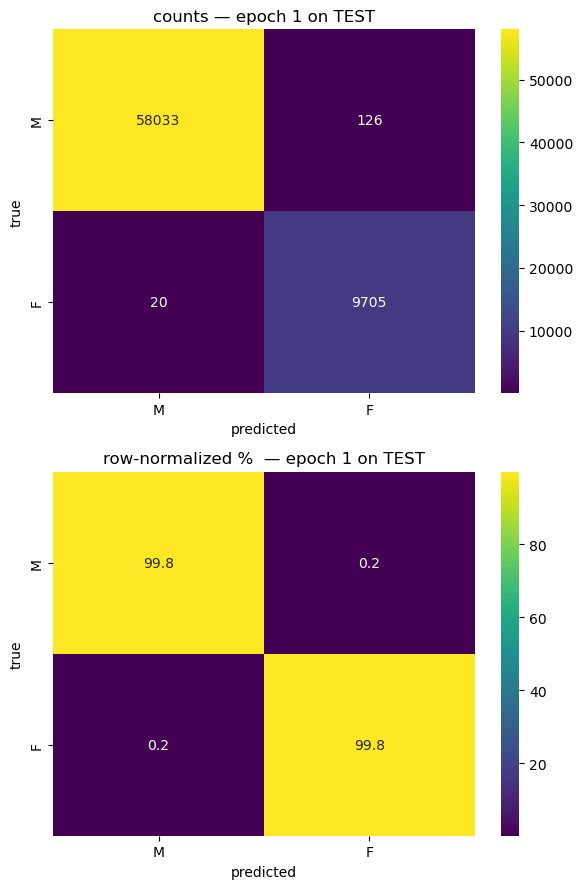

In [20]:
best_epoch_dir = run_dir / "phase2_test" / "epoch_logs" / f"epoch_{phase2_best['epoch']}"
preds_path = best_epoch_dir / "predictions.json"
if not preds_path.exists():
    raise FileNotFoundError(f"Expected predictions at {preds_path}, but it's missing.")

preds_data = json.loads(preds_path.read_text())
y_true_idx = [int(p["gold_raw"]) for p in preds_data]
y_pred_idx = [label2id[p["pred_label"]] for p in preds_data]

str_labels = [str(x) for x in cfg.label_order]
n = len(cfg.label_order)
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(n)))
row_sums = cm.sum(axis=1, keepdims=True)
cm_rel = np.divide(cm.astype(float), row_sums,
                   out=np.zeros_like(cm, dtype=float),
                   where=row_sums != 0) * 100.0

# TEST confusion matrices, stacked vertically: counts on top, row-norm % below.
fig, axes = plt.subplots(2, 1, figsize=(max(6, n * 1.1), max(9, n * 1.8)))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=str_labels, yticklabels=str_labels, ax=axes[0])
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title(f"counts — epoch {phase2_best['epoch']} on TEST")

sns.heatmap(cm_rel, annot=True, fmt=".1f", cmap="viridis",
            xticklabels=str_labels, yticklabels=str_labels, ax=axes[1])
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
axes[1].set_title(f"row-normalized %  — epoch {phase2_best['epoch']} on TEST")

plt.tight_layout()
cm_png = run_dir / "confusion_matrix_test.png"
fig.savefig(cm_png, dpi=120, bbox_inches="tight")
print(f"saved {cm_png.relative_to(PROJECT_ROOT)}")
plt.show()

## Inference spot-check

Eyeball 5 random TEST predictions: provenance + gold vs pred class + a ✓/✗ hit
marker. A quick sanity read on what the model is actually doing — complements
the aggregate metrics + confusion matrix above.

In [21]:
import random as _rnd

_rows = json.loads(preds_path.read_text())
_sample = _rnd.Random(0).sample(_rows, k=min(5, len(_rows)))

udp.banner("INFERENCE SPOT-CHECK — 5 random TEST examples")
for p in _sample:
    gold, pred = p.get("gold_label"), p.get("pred_label")
    hit = "✓" if gold == pred else "✗"
    print(f"  {p['instance_id']}")
    print(f"     file={p.get('file_id', '')}  span={p.get('start_t')}–{p.get('end_t')}")
    print(f"     gold={gold}   pred={pred}   {hit}")
    print()


INFERENCE SPOT-CHECK — 5 random TEST examples
  ParlaMint-HR_2019-10-31-0.u168192_0-22
     file=64LGQKLo4Pw  span=None–None
     gold=M   pred=M   ✓

  ParlaMint-HR_2018-02-28-0.u71750_84-252
     file=Cfti-MnqY7U  span=None–None
     gold=F   pred=F   ✓

  ParlaMint-HR_2019-10-16-0.u165637_721-916
     file=GHHR1sqEfyg  span=None–None
     gold=M   pred=M   ✓

  ParlaMint-HR_2017-10-12-0.u53081_236-344
     file=jus1M1j8vPo  span=None–None
     gold=M   pred=M   ✓

  ParlaMint-HR_2018-04-25-0.u80605_0-11
     file=czW-aQjn04c  span=None–None
     gold=M   pred=M   ✓



## Stage timing

Wall-clock per stage (delta from the previous mark) + total, mm:ss. Prints
whatever marks exist, so a partial run still reports cleanly.

In [22]:
mark("end script")
print_stage_breakdown(STAGE_TIMES)

stage timing (delta from previous mark)
------------------------
  literal start  00:00
  data prep      00:09
  model prep     02:44
  end phase 1    16:41
  end phase 2    28:51
  end script     00:02
------------------------
  TOTAL          48:28


## What's next

This run wrote per-epoch logs + a saved best model under `runs/`. Chapter 5
(`5_analysis/`) loads run directories like this one for error analysis and
cross-run comparison.

Same dataset, second target: change `Config.target` and re-run.
`32_train_regression` is the twin for sentiment-logit / age regression.